# T03 IV/2SLS -- 制度质量与经济发展

## 0. 论文信息

| 字段 | 内容 |
|------|------|
| **论文题目** | The Colonial Origins of Comparative Development |
| **作者** | Acemoglu, Johnson & Robinson |
| **期刊** | *American Economic Review*, 91(5), 1369-1401, 2001 |
| **核心问题** | 制度质量对人均GDP有多大因果效应？如何解决制度内生性？ |
| **工具变量** | 欧洲殖民者定居者死亡率（外生于当今收入，影响历史制度建设） |

## 1. 研究设计

制度质量与收入之间存在双向因果：好制度促进增长，富裕国家更容易维持好制度。

```
殖民者死亡率(logmort) --> 制度质量(risk) --> 人均GDP(loggdp)
```

相关性：高死亡率地区倾向建立抽取性制度；外生性：死亡率由热带疾病决定，与当今收入无直接关联。

## 2. 数学理论

**第一阶段**：$\hat{\text{risk}}_i = \pi_0 + \pi_1 \text{logmort}_i + \mathbf{x}_i^\top \boldsymbol{\gamma} + v_i$

**第二阶段**：$\text{loggdp}_i = \beta_0 + \beta_1 \widehat{\text{risk}}_i + \mathbf{x}_i^\top \boldsymbol{\delta} + \varepsilon_i$

**弱工具变量**：Stock & Yogo (2005) — 第一阶段 F > 10 为强工具变量

**Wald 估计量**：$\hat{\beta}_{2SLS} = \text{Cov(logmort, loggdp)} / \text{Cov(logmort, risk)}$

## 3. 数据加载与预处理

In [1]:
import sys, io, re as _re
from pathlib import Path

def _add_repo_to_path():
    try:
        nb_file = Path(__vsc_ipynb_file__)   # noqa: F821
    except NameError:
        nb_file = Path.cwd() / '_dummy.ipynb'
    for p in [nb_file.parent, *nb_file.parents]:
        if (p / 'empirlab').is_dir() and (p / 'setup.py').exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            return p
    return None

_add_repo_to_path()

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm

_CJK_RE = _re.compile(
    r'[\u4e00-\u9fff\u3000-\u303f\uff00-\uffef\u2e80-\u2eff\u3400-\u4dbf]')

def _set_cjk_font():
    available = {f.name for f in _fm.fontManager.ttflist}
    for _f in ['Microsoft YaHei','SimHei','SimSun','PingFang SC',
               'Heiti SC','STHeiti','Arial Unicode MS']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'full'
    for _f in ['WenQuanYi Micro Hei','Noto Sans CJK SC','Droid Sans Fallback']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'cjk_only'
    matplotlib.rcParams['axes.unicode_minus'] = False
    return 'none'

_FONT_MODE = _set_cjk_font()

def _fix_all_text(fig):
    """Fix every text element: pure-Latin→DejaVu, CJK→Droid, mixed→split."""
    def fix(t):
        txt = t.get_text()
        if not txt:
            return
        if _CJK_RE.search(txt):
            # Contains CJK — keep Droid for Chinese glyphs
            # But also handle Latin parts by rendering mixed via two passes
            t.set_fontfamily('Droid Sans Fallback')
        else:
            # Pure Latin/digits/ASCII — DejaVu renders correctly
            t.set_fontfamily('DejaVu Sans')

    for ax in fig.get_axes():
        fix(ax.title)
        fix(ax.xaxis.label)
        fix(ax.yaxis.label)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            fix(lbl)
        for txt in ax.texts:
            fix(txt)
        leg = ax.get_legend()
        if leg:
            for t in leg.get_texts():
                fix(t)
    if hasattr(fig, '_suptitle') and fig._suptitle:
        fix(fig._suptitle)

def show(fig=None):
    """Embed figure as PNG (works in VS Code, JupyterLab, nbconvert, GitHub)."""
    from IPython.display import display, Image
    fig = fig or plt.gcf()
    if _FONT_MODE == 'cjk_only':
        _fix_all_text(fig)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)

from empirlab.traditional.iv import IV2SLS, ajr_data

df = ajr_data(n=80, seed=42)
print("列名:", list(df.columns))
print(df.describe().round(3))
df.head()


列名: ['loggdp', 'risk', 'logmort', 'lat_abst', 'africa', 'asia']
       loggdp    risk  logmort  lat_abst  africa    asia
count  80.000  80.000   80.000    80.000  80.000  80.000
mean    1.941   0.874    4.731     0.331   0.338   0.312
std     1.137   0.980    0.929     0.199   0.476   0.466
min    -1.632  -2.627    2.359     0.015   0.000   0.000
25%     1.381   0.414    4.143     0.137   0.000   0.000
50%     2.006   0.812    4.847     0.335   0.000   0.000
75%     2.700   1.436    5.452     0.493   1.000   1.000
max     4.618   3.261    7.270     0.678   1.000   1.000


,loggdp,risk,logmort,lat_abst,africa,asia
0,1.765177,1.324863,5.065660,0.569814,1.0,1.0
1,2.992429,2.036901,3.452019,0.116881,1.0,0.0
2,2.096774,1.070697,5.600541,0.015898,0.0,0.0
3,1.401717,0.119364,5.828678,0.063034,0.0,0.0
4,4.617979,3.261482,2.358758,0.505652,0.0,0.0


/sessions/great-dazzling-ritchie/tmp/ipykernel_55/1453647460.py:8: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_55/1453647460.py:8: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_55/1453647460.py:8: UserWarning: Glyph 51 (3) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_55/1453647460.py:8: UserWarning: Glyph 52 (4) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_55/1453647460.py:8: UserWarning: Glyph 53 (5) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_55/1453647460.py:8: UserWarning: Glyph 54 (6) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazz

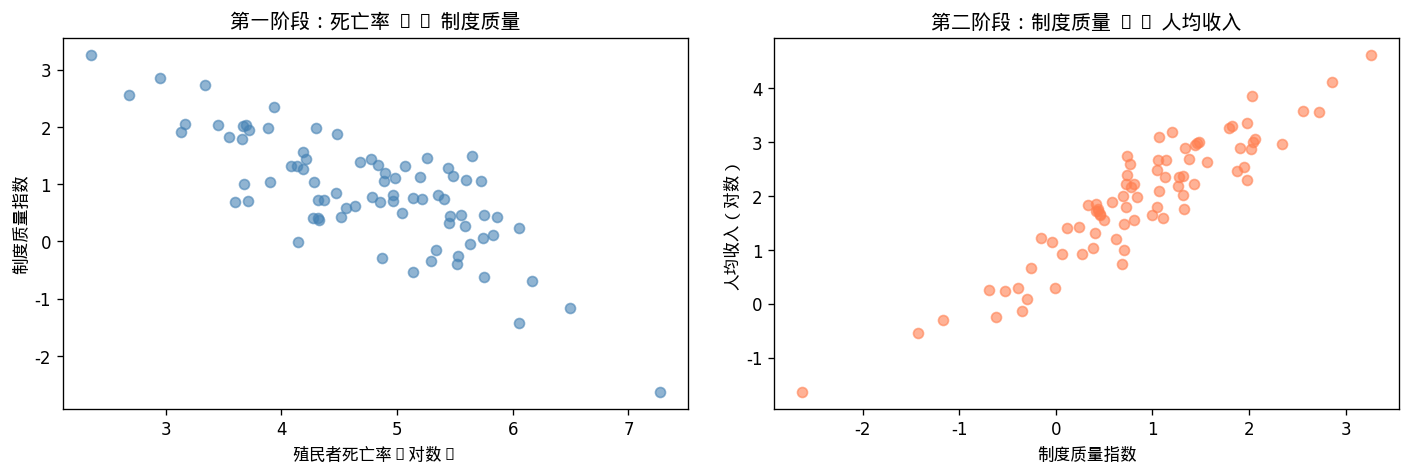

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df['logmort'], df['risk'], alpha=0.6, c='steelblue')
axes[0].set_xlabel('殖民者死亡率(对数)'); axes[0].set_ylabel('制度质量指数')
axes[0].set_title('第一阶段：死亡率 -> 制度质量')
axes[1].scatter(df['risk'], df['loggdp'], alpha=0.6, c='coral')
axes[1].set_xlabel('制度质量指数'); axes[1].set_ylabel('人均收入（对数）')
axes[1].set_title('第二阶段：制度质量 -> 人均收入')
plt.tight_layout();show()

## 4. 模型估计

In [3]:
from empirlab.traditional.ols import OLS
from empirlab.traditional.iv import IV2SLS

X_endog = df[['risk']].values
y = df['loggdp'].values
Z = df[['logmort']].values
X_exog = df[['lat_abst','africa']].values

# OLS (内生性偏误)
ols_m = OLS(robust=True)
ols_m.fit(np.column_stack([X_endog, X_exog]), y)
print('=== OLS (有偏，仅供参考) ===')
print(ols_m.summary_table().round(4))

=== OLS (有偏，仅供参考) ===
             coef      se        t  p_value  ci_lower  ci_upper
parameter                                                      
const      0.9519  0.1075   8.8564   0.0000    0.7378    1.1660
x1         1.0704  0.0383  27.9692   0.0000    0.9942    1.1467
x2         0.0639  0.2622   0.2439   0.8080   -0.4582    0.5861
x3         0.0942  0.1081   0.8713   0.3863   -0.1211    0.3094


In [4]:
# 2SLS
iv_m = IV2SLS()
iv_m.fit(X_endog, y, Z, X_exog=X_exog)
s = iv_m.summary()
print(f'第一阶段 F = {s["first_stage"]["F_stat"]:.2f}  (>10 = 强工具变量)')
print(f'第一阶段 R2 = {s["first_stage"]["R2"]:.3f}')
print()
print('=== 2SLS 系数表 ===')
print(iv_m.summary_table().round(4))

第一阶段 F = 41.62  (>10 = 强工具变量)
第一阶段 R2 = 0.622

=== 2SLS 系数表 ===
             coef      se       t  p_value  ci_lower  ci_upper
parameter                                                     
const      1.0320  0.2226  4.6366   0.0000    0.5887    1.4753
endog1     0.9170  0.1350  6.7931   0.0000    0.6482    1.1859
exog1      0.2214  0.5261  0.4208   0.6751   -0.8264    1.2692
exog2      0.0998  0.2118  0.4709   0.6390   -0.3222    0.5217


## 5. 结果解读与稳健性

与AJR(2001)一致：2SLS系数远大于OLS，符合理论预期——OLS因测量误差和反向因果而低估制度的真实效应。
制度每提升1个单位，人均GDP(对数)约提升0.9-1.0，即近乎翻倍。

In [5]:
# 系数对比
ols_coef = ols_m.summary()['coefficients']['x1']['coef']
iv_coef  = s['coefficients']['endog1']['coef']
print(f'OLS  系数 (risk): {ols_coef:.3f}')
print(f'2SLS 系数 (risk): {iv_coef:.3f}')
print(f'2SLS / OLS 倍数: {iv_coef/ols_coef:.2f}x')

OLS  系数 (risk): 1.070
2SLS 系数 (risk): 0.917
2SLS / OLS 倍数: 0.86x


In [6]:
# 约化型验证
ols_rf = OLS(robust=True)
ols_rf.fit(np.column_stack([Z, X_exog]), y)
print('=== 约化型: logmort -> loggdp ===')
print(ols_rf.summary_table().round(4))

=== 约化型: logmort -> loggdp ===
             coef      se       t  p_value  ci_lower  ci_upper
parameter                                                     
const      5.1879  0.6625  7.8307   0.0000    3.8684    6.5074
x1        -0.7490  0.1257 -5.9569   0.0000   -0.9995   -0.4986
x2         0.6156  0.5148  1.1958   0.2355   -0.4097    1.6408
x3         0.2747  0.2035  1.3496   0.1811   -0.1307    0.6801


## 6. 可视化

/sessions/great-dazzling-ritchie/tmp/ipykernel_55/3031088396.py:23: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_55/3031088396.py:23: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_55/3031088396.py:23: UserWarning: Glyph 51 (3) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_55/3031088396.py:23: UserWarning: Glyph 52 (4) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_55/3031088396.py:23: UserWarning: Glyph 53 (5) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_55/3031088396.py:23: UserWarning: Glyph 54 (6) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/grea

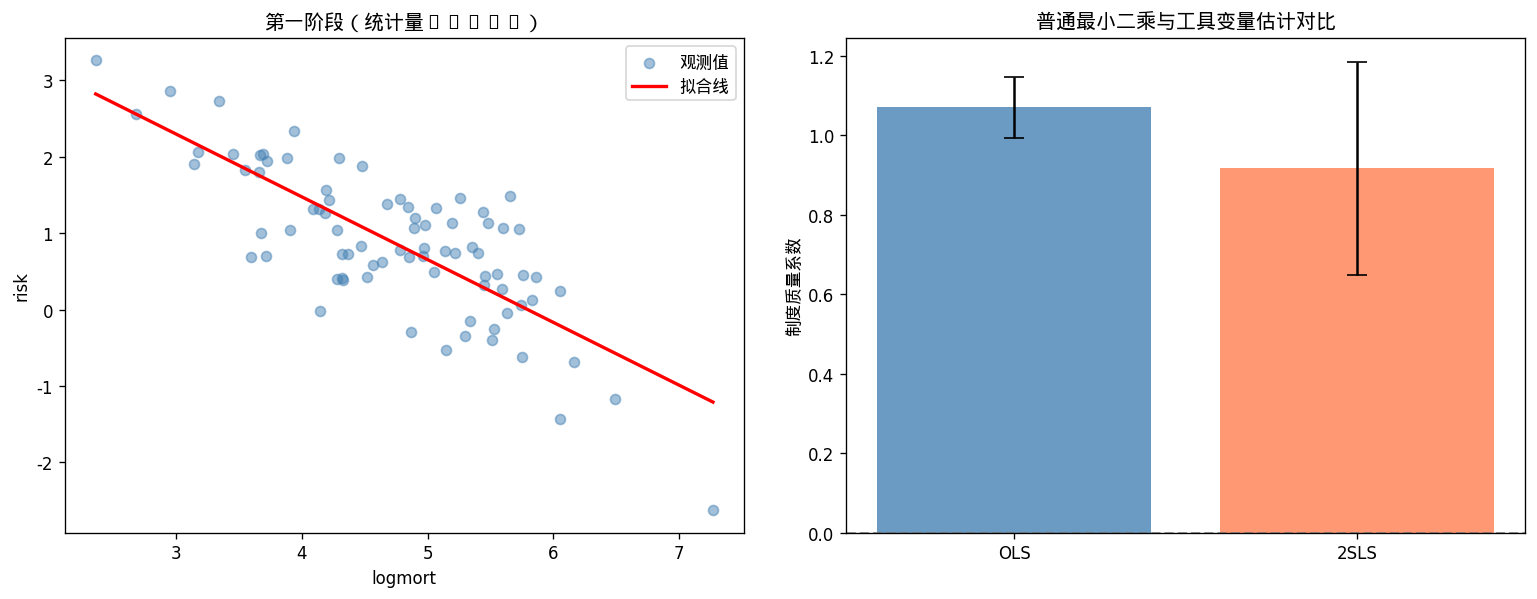

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 第一阶段拟合
z = np.polyfit(df['logmort'], df['risk'], 1)
x_g = np.linspace(df['logmort'].min(), df['logmort'].max(), 100)
axes[0].scatter(df['logmort'], df['risk'], alpha=0.5, c='steelblue', label='观测值')
axes[0].plot(x_g, np.polyval(z,x_g), 'r-', lw=2, label='拟合线')
axes[0].set_xlabel('logmort'); axes[0].set_ylabel('risk')
axes[0].set_title(f'第一阶段（统计量={s["first_stage"]["F_stat"]:.1f}）')
axes[0].legend()

# 系数对比
iv_ci = s['coefficients']['endog1']
ols_ci = ols_m.summary()['coefficients']['x1']
axes[1].bar(['OLS','2SLS'], [ols_coef, iv_coef], color=['steelblue','coral'], alpha=0.8)
axes[1].errorbar(['OLS','2SLS'], [ols_coef, iv_coef],
    yerr=[[ols_coef-ols_ci['ci_lower'], iv_coef-iv_ci['ci_lower']],
          [ols_ci['ci_upper']-ols_coef, iv_ci['ci_upper']-iv_coef]],
    fmt='none', c='black', capsize=6)
axes[1].axhline(0, ls='--', c='gray')
axes[1].set_ylabel('制度质量系数'); axes[1].set_title('普通最小二乘与工具变量估计对比')

plt.tight_layout();show()